<a href="https://colab.research.google.com/github/malikbaqi12/Faculty-Workload-FALL-2026/blob/main/faculty_workload_backend.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Faculty Workload Allocation — Backend Notebook

Full backend pipeline for the Faculty Workload Allocation and Course
Recommendation System, developed and runnable in Google Colab: data
loading (Excel **or Word .docx** — e.g. a workload table pasted straight
into a department Word template), Computing Core Course detection,
faculty teaching-history building, content-based suitability scoring
(TF-IDF/cosine similarity), constraint-based optimization (integer
programming), and PDF report generation.

Sections 1–5 below are extracted directly from `app.py` (the Streamlit
frontend)'s backend code, so the notebook and the deployed app always run
the identical pipeline — Section 6 just calls `run_pipeline(...)`, the
same function `app.py` calls.

**Why content-based + optimization, not a trained ML model (yet):** one
semester's workload sheet gives a single labeled example per faculty
member — not enough to train a classifier/ranker that generalizes. The
score is a transparent hybrid: TF-IDF/cosine similarity between a
faculty member's teaching history and each candidate course, blended
with rule-based bonuses/penalties for the constraints in the brief
(Computing Core Course coverage, repeat-avoidance). An integer program
then turns those scores into a feasible allocation.

**If you don't have a separate Scheme of Studies yet:** that's fine —
skip uploading one in Section 6 and the notebook uses the previous
semester's own course list as the candidate pool for the upcoming
semester (with a clear warning noting that's what happened). It just
means it can only recommend courses it has already seen taught before,
not brand-new ones — upload a real Scheme of Studies once you have it
for a more accurate result.

In [1]:
!pip -q install pandas numpy scikit-learn pulp reportlab openpyxl pdfplumber python-docx matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 2.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 37.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 46.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 37.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 42.2 MB/s eta 0:00:00


## Imports

In [2]:
"""
app.py — Faculty Workload Allocation and Course Recommendation System

Single-file Streamlit application. All backend logic (data loading,
Computing Core Course detection, faculty teaching history, content-based
suitability scoring, constraint-based optimization, and PDF report
generation) lives in this file, organized into clearly labeled sections
below. The companion notebook (faculty_workload_backend.ipynb) contains
the same pipeline for offline experimentation / Google Colab use.

Run with:
    streamlit run app.py
"""

from __future__ import annotations

import io
import re
import traceback
from dataclasses import dataclass, field
from typing import Optional

import numpy as np
import pandas as pd
import pulp
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from reportlab.lib import colors
from reportlab.lib.pagesizes import letter
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib.units import inch
from reportlab.platypus import (
    SimpleDocTemplate, Table, TableStyle, Paragraph, Spacer, PageBreak,
)

## Section 1 — Data preprocessing

Flexible column matching, automatic header-row detection (handles a
title row pasted above the real header — exactly what the department's
Word/Excel export looks like), Word-table extraction with
section-divider rows filtered out, newline cleanup for wrapped cells,
and Computing Core Course detection with word-boundary alias matching so
short aliases like "se" don't false-match inside words like "security".

In [3]:
# =============================================================================
# SECTION 1 — DATA PREPROCESSING
# (workload / scheme-of-studies loaders, Computing Core Course detection)
# =============================================================================

COMPUTING_CORE_COURSES = {
    "Programming Fundamentals": ["programming fundamental", "programming fundamentals", "intro to computer", "introduction to computing"],
    "Object-Oriented Programming": ["object oriented programming", "oop"],
    "Data Structures": ["data structure", "data structures", "ds"],
    "Computer Networks": ["computer network", "computer networks"],
    "Database Management Systems": ["database system", "database systems", "database management", "dbms"],
    "Analysis of Algorithms": ["analysis of algorithm", "analysis of algorithms", "aoa"],
    "Software Engineering": ["software engineering", "se"],
}
CORE_ALIAS_LOOKUP = {
    alias: canonical
    for canonical, aliases in COMPUTING_CORE_COURSES.items()
    for alias in aliases
}

MAX_CREDIT_HOURS = 9
MAX_THEORY_COURSES = 3
MAX_LAB_COURSES = 1
MAX_PREVIOUSLY_TAUGHT = 1
MAX_FACULTY_PER_COURSE = 2  # duplicate/comparative recommendation cap


def _norm(s: object) -> str:
    if s is None or (isinstance(s, float) and pd.isna(s)):
        return ""
    s = str(s).lower().strip()
    s = re.sub(r"[^a-z0-9 ]", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s


def is_core_course(course_name: str) -> Optional[str]:
    """Return the canonical Computing Core Course name if this course is one, else None."""
    n = _norm(course_name)
    if not n:
        return None
    # Longest aliases first, matched on word boundaries, so short aliases
    # (e.g. "se", "ds") can't false-match inside unrelated words like "security".
    for alias in sorted(CORE_ALIAS_LOOKUP, key=len, reverse=True):
        if re.search(rf"\b{re.escape(alias)}\b", n):
            return CORE_ALIAS_LOOKUP[alias]
    return None


def is_lab(theory_lab_value: str) -> bool:
    return "lab" in _norm(theory_lab_value)


def _clean_text(s: object) -> str:
    """
    Collapse embedded newlines/extra whitespace from wrapped Excel cells
    (e.g. "Ms. Samra\\nJamil" -> "Ms. Samra Jamil") so the same faculty
    member or course isn't accidentally treated as two different ones just
    because of how a cell happened to wrap.
    """
    if s is None or (isinstance(s, float) and pd.isna(s)):
        return ""
    return re.sub(r"\s+", " ", str(s).replace("\n", " ").replace("\r", " ")).strip()


WORKLOAD_COLUMN_ALIASES = {
    "faculty_name": ["faculty name", "faculty", "instructor", "teacher"],
    "course_code": ["course code", "code"],
    "course_name": ["course name", "course", "subject"],
    "theory_lab": ["theory lab", "theory/lab", "type", "th lab"],
    "semester": ["semester", "sem"],
    "credit_hours": ["cr hr", "crhr", "credit hours", "credit hr", "cr h", "credit"],
    "contact_hours": ["cn hr", "cnhr", "contact hours", "contact hr", "con hr", "con h"],
    "program": ["program", "programme", "degree"],
}

SCHEME_COLUMN_ALIASES = {
    "course_code": ["course code", "code"],
    "course_name": ["course name", "course", "subject", "course title"],
    "credit_hours": ["credit hours", "cr hr", "crhr", "credit hr", "credit"],
    "theory_lab": ["theory lab", "theory/lab", "type"],
    "semester": ["semester", "sem"],
    "program": ["program", "programme", "degree"],
}


def _match_columns(columns, alias_map: dict) -> dict:
    norm_cols = {_norm(c): c for c in columns}
    result = {}
    for canonical, aliases in alias_map.items():
        for alias in aliases:
            if alias in norm_cols:
                result[canonical] = norm_cols[alias]
                break
        else:
            for norm_c, orig_c in norm_cols.items():
                if any(a in norm_c for a in aliases):
                    result[canonical] = orig_c
                    break
    return result


def _find_header_row(raw_no_header: pd.DataFrame, alias_map: dict, required_keys: list, max_scan: int = 10) -> int:
    """
    Real-world exports (like a Word table pasted into Excel) often have one or
    more title rows above the actual column headers, e.g.:
        Row 0: "AI Programme Workload Spring 2026"
        Row 1: "Faculty Add"
        Row 2: "Faculty Name | Course Code | Course Name | ..."   <- real header
    Reading with header=0 in that case silently produces a DataFrame with the
    real headers as data and no recognizable columns, which downstream ends up
    as an empty, hard-to-diagnose result. This scans the first few rows and
    picks the one that best matches the expected column aliases.
    """
    best_row, best_score = 0, -1
    scan_limit = min(max_scan, len(raw_no_header))
    for i in range(scan_limit):
        norm_vals = {_norm(v) for v in raw_no_header.iloc[i].tolist()}
        score = 0
        for key in required_keys:
            if any(any(alias == nv or alias in nv for nv in norm_vals) for alias in alias_map[key]):
                score += 1
        if score > best_score:
            best_score = score
            best_row = i
    return best_row


def _read_excel_with_smart_header(file_path_or_buffer, alias_map: dict, required_keys: list) -> pd.DataFrame:
    """Read an Excel file, auto-detecting which row is the real header row."""
    if hasattr(file_path_or_buffer, "seek"):
        file_path_or_buffer.seek(0)
    raw_no_header = pd.read_excel(file_path_or_buffer, header=None)

    header_row = _find_header_row(raw_no_header, alias_map, required_keys)

    if hasattr(file_path_or_buffer, "seek"):
        file_path_or_buffer.seek(0)
    return pd.read_excel(file_path_or_buffer, header=header_row)


def _read_docx_table(file_path_or_buffer, alias_map: dict, required_keys: list) -> pd.DataFrame:
    """
    Extract a table from a Word (.docx) document, such as the department's
    workload table pasted straight into Word. Scans every table in the
    document and every row near the top of each table to find the row that
    best matches the expected column headers (handles a bold title
    paragraph above the table, or a table with its own header a row or two
    down), then builds a DataFrame from everything below that header row.
    """
    import docx

    if hasattr(file_path_or_buffer, "seek"):
        file_path_or_buffer.seek(0)
    document = docx.Document(file_path_or_buffer)

    if not document.tables:
        raise ValueError("No tables were found in the Word document.")

    best_table, best_header_row, best_score = None, 0, -1
    for table in document.tables:
        scan_limit = min(5, len(table.rows))
        for i in range(scan_limit):
            norm_vals = {_norm(cell.text) for cell in table.rows[i].cells}
            score = 0
            for key in required_keys:
                if any(any(alias == nv or alias in nv for nv in norm_vals) for alias in alias_map[key]):
                    score += 1
            if score > best_score:
                best_score = score
                best_table = table
                best_header_row = i

    if best_table is None or best_score <= 0:
        raise ValueError(
            "Could not find a table with recognizable column headers "
            "(e.g. Faculty Name / Course Name) anywhere in the Word document."
        )

    header_cells = [cell.text.strip() for cell in best_table.rows[best_header_row].cells]
    data_rows = []
    for row in best_table.rows[best_header_row + 1:]:
        cells = [cell.text for cell in row.cells]
        # Section-divider rows (e.g. "CS Merge Labs", "Combine") are stored by
        # python-docx as a horizontally-merged cell repeated across every
        # column — i.e. every non-empty cell in the row has the same text.
        # Those are sub-headings in the source table, not real faculty/course
        # data, so drop them here rather than let them masquerade as a course.
        non_empty = {c.strip() for c in cells if c.strip()}
        if len(non_empty) <= 1:
            continue
        data_rows.append(cells)

    return pd.DataFrame(data_rows, columns=header_cells)


def _infer_filename(file_path_or_buffer, filename_hint: str = "") -> str:
    if filename_hint:
        return filename_hint
    if isinstance(file_path_or_buffer, str):
        return file_path_or_buffer
    return getattr(file_path_or_buffer, "name", "") or ""


def _read_tabular_file(file_path_or_buffer, alias_map: dict, required_keys: list, filename_hint: str = "") -> tuple:
    """
    Dispatch to the right reader (.docx table extraction or Excel with
    smart header detection) based on the file's name/extension. Returns
    (DataFrame, list_of_warnings).
    """
    name = _infer_filename(file_path_or_buffer, filename_hint).lower()
    warnings = []
    if name.endswith(".docx"):
        df = _read_docx_table(file_path_or_buffer, alias_map, required_keys)
        warnings.append(
            "Data was extracted from a Word (.docx) table — please spot-check merged cells "
            "and any values that ran together before relying on the allocation."
        )
    else:
        df = _read_excel_with_smart_header(file_path_or_buffer, alias_map, required_keys)
    return df, warnings


@dataclass
class LoadResult:
    df: pd.DataFrame
    warnings: list


def load_previous_workload(file_path_or_buffer, default_program: str = "", filename_hint: str = "") -> LoadResult:
    """
    Load previous semester faculty workload from Excel (.xlsx) or Word (.docx)
    into a normalized DataFrame: faculty_name, course_code, course_name,
    theory_lab, semester, credit_hours, contact_hours, program, is_lab,
    core_course. Merged-cell/repeated faculty names are forward-filled, and
    text is cleaned of stray newlines from wrapped cells.
    """
    raw, warnings = _read_tabular_file(
        file_path_or_buffer, WORKLOAD_COLUMN_ALIASES, ["faculty_name", "course_name"], filename_hint
    )
    raw = raw.dropna(how="all")

    colmap = _match_columns(raw.columns, WORKLOAD_COLUMN_ALIASES)
    missing = [c for c in ["faculty_name", "course_name"] if c not in colmap]
    if missing:
        raise ValueError(
            f"Could not find required column(s) {missing} in the workload file. "
            f"Found columns: {list(raw.columns)}"
        )

    df = pd.DataFrame()
    for canonical, orig in colmap.items():
        df[canonical] = raw[orig]

    df["faculty_name"] = df["faculty_name"].ffill()
    df = df[~(df["course_name"].isna() & df.get("course_code", pd.Series([None] * len(df))).isna())]
    df = df[df["course_name"].notna()]

    for col in ["course_code", "theory_lab", "semester", "credit_hours", "contact_hours", "program"]:
        if col not in df.columns:
            df[col] = None

    df["program"] = df["program"].fillna(default_program or "")
    df["credit_hours"] = pd.to_numeric(df["credit_hours"], errors="coerce")
    if df["credit_hours"].isna().any():
        warnings.append("Some rows had a non-numeric or missing credit-hour value; they were treated as 0 for totals.")
    df["credit_hours"] = df["credit_hours"].fillna(0)

    df["is_lab"] = df["theory_lab"].apply(is_lab)
    df["faculty_name"] = df["faculty_name"].apply(_clean_text)
    df["course_name"] = df["course_name"].apply(_clean_text)
    df["course_code"] = df["course_code"].apply(_clean_text)
    df["core_course"] = df["course_name"].apply(is_core_course)

    df = df.reset_index(drop=True)
    if df.empty:
        raise ValueError(
            "The workload file was read, but no usable rows remained after cleaning. "
            "Check that the file has a header row (Faculty Name, Course Code, Course Name, ...) "
            "followed directly by data rows, with no extra title rows in between that couldn't be skipped."
        )
    return LoadResult(df=df, warnings=warnings)


def load_scheme_of_studies(file_path_or_buffer, program: str, filename_hint: str = "") -> LoadResult:
    """Load a Scheme of Studies file (Excel, Word, or PDF) for one program."""
    name = _infer_filename(file_path_or_buffer, filename_hint).lower()
    is_pdf = name.endswith(".pdf")

    if is_pdf:
        df = _extract_scheme_from_pdf(file_path_or_buffer)
        warnings = [
            "Scheme was extracted from a PDF using table parsing — "
            "please spot-check course codes and credit hours before relying on the allocation."
        ]
    else:
        df, warnings = _read_tabular_file(file_path_or_buffer, SCHEME_COLUMN_ALIASES, ["course_name"], filename_hint)

    df = df.dropna(how="all")
    colmap = _match_columns(df.columns, SCHEME_COLUMN_ALIASES)
    missing = [c for c in ["course_name"] if c not in colmap]
    if missing:
        raise ValueError(
            f"Could not find required column(s) {missing} in the {program} scheme file. "
            f"Found columns: {list(df.columns)}"
        )

    out = pd.DataFrame()
    for canonical, orig in colmap.items():
        out[canonical] = df[orig]

    out = out[out["course_name"].notna()].reset_index(drop=True)
    for col in ["course_code", "credit_hours", "theory_lab", "semester"]:
        if col not in out.columns:
            out[col] = None

    out["program"] = program
    out["credit_hours"] = pd.to_numeric(out["credit_hours"], errors="coerce").fillna(3)
    out["is_lab"] = out["theory_lab"].apply(is_lab)
    out["course_name"] = out["course_name"].apply(_clean_text)
    out["course_code"] = out["course_code"].apply(_clean_text)
    out["core_course"] = out["course_name"].apply(is_core_course)

    if out.empty:
        raise ValueError(
            f"The {program} scheme file was read, but no usable course rows remained after cleaning. "
            "Check that the file has a header row (Course Code, Course Name, Credit Hours, ...) "
            "followed directly by data rows, with no extra title rows in between that couldn't be skipped."
        )
    return LoadResult(df=out, warnings=warnings)


def _extract_scheme_from_pdf(file_path_or_buffer) -> pd.DataFrame:
    import pdfplumber

    rows = []
    header = None
    with pdfplumber.open(file_path_or_buffer) as pdf:
        for page in pdf.pages:
            for table in page.extract_tables() or []:
                if not table:
                    continue
                start = 0
                if header is None:
                    header = table[0]
                    start = 1
                for row in table[start:]:
                    rows.append(row)

    if header is None or not rows:
        raise ValueError("No tables could be extracted from the scheme PDF. Try exporting it as Excel instead.")

    return pd.DataFrame(rows, columns=header)


def build_faculty_history(workload_df: pd.DataFrame) -> dict:
    """Faculty Member -> prior courses, credit-hour totals, core courses taught, theory/lab counts."""
    history = {}
    for faculty, group in workload_df.groupby("faculty_name"):
        history[faculty] = {
            "courses": group["course_name"].tolist(),
            "course_codes": group.get("course_code", pd.Series(dtype=object)).tolist(),
            "credit_hours_total": float(group["credit_hours"].sum()),
            "core_courses_taught": [c for c in group["core_course"].tolist() if isinstance(c, str) and c],
            "theory_count": int((~group["is_lab"]).sum()),
            "lab_count": int(group["is_lab"].sum()),
        }
    return history


## Section 2 — Recommendation model (content-based suitability scoring)

In [4]:
# =============================================================================
# SECTION 2 — RECOMMENDATION MODEL (content-based suitability scoring)
# =============================================================================
# Why content-based + rules, not a trained ML model: a single semester's
# workload gives one labeled example per faculty member — not enough to
# train a classifier/ranker that generalizes. Score = TF-IDF/cosine
# similarity between a faculty member's teaching-history text and each
# candidate course, blended with bonuses/penalties for the constraints
# in the brief (Computing Core Course coverage, repeat-avoidance).

@dataclass
class SuitabilityResult:
    scores: pd.DataFrame
    explanations: dict = field(default_factory=dict)


def _faculty_profile_text(history_entry: dict) -> str:
    return " ".join(history_entry.get("courses", [])) or "no prior courses on record"


def _course_text(row: pd.Series) -> str:
    parts = [str(row.get("course_name", "")), str(row.get("program", "") or "")]
    core = row.get("core_course")
    if isinstance(core, str) and core:
        parts.append(core)
    return " ".join(parts)


def compute_suitability_scores(
    scheme_df: pd.DataFrame,
    faculty_history: dict,
    repeat_penalty: float = 0.5,
    core_bonus: float = 0.25,
    core_repeat_penalty: float = 0.3,
) -> SuitabilityResult:
    faculty_names = list(faculty_history.keys())
    if not faculty_names:
        raise ValueError("No faculty history available to score against.")
    if scheme_df.empty:
        raise ValueError(
            "No candidate courses were found in the Scheme of Studies file(s) after cleaning. "
            "Check the uploaded scheme file(s) have a recognizable Course Name column."
        )

    course_texts = scheme_df.apply(_course_text, axis=1).tolist()
    faculty_texts = [_faculty_profile_text(faculty_history[f]) for f in faculty_names]

    vectorizer = TfidfVectorizer(stop_words="english")
    tfidf = vectorizer.fit_transform(course_texts + faculty_texts)
    course_vecs = tfidf[: len(course_texts)]
    faculty_vecs = tfidf[len(course_texts):]

    sim_matrix = cosine_similarity(faculty_vecs, course_vecs)

    rows = []
    explanations = {}

    for fi, faculty in enumerate(faculty_names):
        hist = faculty_history[faculty]
        prev_courses_norm = {c.strip().lower() for c in hist.get("courses", [])}

        for ci, (_, course_row) in enumerate(scheme_df.iterrows()):
            base_sim = float(sim_matrix[fi, ci])
            score = base_sim
            reasons = [f"content similarity to prior teaching = {base_sim:.2f}"]

            course_name = str(course_row["course_name"]).strip()
            core = course_row.get("core_course")

            already_taught = course_name.lower() in prev_courses_norm
            if already_taught:
                score -= repeat_penalty
                reasons.append("penalized: identical course taught last semester (Rule B)")

            if isinstance(core, str) and core:
                score += core_bonus
                reasons.append(f"bonus: is a Computing Core Course ({core}) (Rule C)")
                if core in hist.get("core_courses_taught", []):
                    score -= core_repeat_penalty
                    reasons.append("penalized: faculty already taught this exact core course last semester")
                elif hist.get("core_courses_taught"):
                    reasons.append("note: faculty taught a different core course last semester — this diversifies core coverage")

            score = max(score, 0.0)
            rows.append({
                "faculty_name": faculty,
                "course_name": course_name,
                "course_code": course_row.get("course_code"),
                "is_lab": bool(course_row.get("is_lab", False)),
                "credit_hours": float(course_row.get("credit_hours", 3) or 3),
                "core_course": core,
                "program": course_row.get("program"),
                "already_taught_previously": already_taught,
                "score": round(score, 4),
            })
            explanations[(faculty, str(course_row.get("course_code")))] = "; ".join(reasons)

    return SuitabilityResult(scores=pd.DataFrame(rows), explanations=explanations)


## Section 3 — Optimization (constraint-based final allocation, PuLP/CBC)

In [5]:
# =============================================================================
# SECTION 3 — OPTIMIZATION (constraint-based final allocation, PuLP/CBC)
# =============================================================================
# Decision variable x[f, c] = 1 if faculty f is assigned course c.
# Enforces: <=9 credit hours/faculty, <=3 theory + <=1 lab/faculty,
# <=1 previously-taught course repeated/faculty, <=2 faculty per course.
# Objective: maximize total suitability score + a soft per-faculty bonus
# for having at least one Computing Core Course (kept soft so the solver
# stays feasible when core seats are scarce).

@dataclass
class AllocationResult:
    assignments: pd.DataFrame
    unallocated_courses: pd.DataFrame
    faculty_summary: pd.DataFrame
    solver_status: str


def optimize_allocation(
    scores_df: pd.DataFrame,
    explanations: dict,
    max_credit_hours: int = MAX_CREDIT_HOURS,
    max_theory: int = MAX_THEORY_COURSES,
    max_lab: int = MAX_LAB_COURSES,
    max_faculty_per_course: int = MAX_FACULTY_PER_COURSE,
    core_course_soft_bonus: float = 2.0,
) -> AllocationResult:
    faculty_list = scores_df["faculty_name"].unique().tolist()

    scores_df = scores_df.copy()
    scores_df["course_key"] = scores_df.apply(lambda r: f"{r['course_code']}||{r['course_name']}", axis=1)
    course_keys = scores_df[["course_code", "course_name", "course_key"]].drop_duplicates()

    prob = pulp.LpProblem("faculty_workload_allocation", pulp.LpMaximize)

    x = {
        (row["faculty_name"], row["course_key"]): pulp.LpVariable(
            f"x_{row['faculty_name']}_{row['course_key']}".replace(" ", "_"), cat="Binary"
        )
        for _, row in scores_df.iterrows()
    }
    has_core = {f: pulp.LpVariable(f"has_core_{f}".replace(" ", "_"), cat="Binary") for f in faculty_list}

    prob += (
        pulp.lpSum(x[(r["faculty_name"], r["course_key"])] * r["score"] for _, r in scores_df.iterrows())
        + pulp.lpSum(has_core[f] * core_course_soft_bonus for f in faculty_list)
    )

    for f in faculty_list:
        f_rows = scores_df[scores_df["faculty_name"] == f]

        prob += pulp.lpSum(x[(f, r["course_key"])] * r["credit_hours"] for _, r in f_rows.iterrows()) <= max_credit_hours

        theory_rows = f_rows[~f_rows["is_lab"]]
        prob += pulp.lpSum(x[(f, r["course_key"])] for _, r in theory_rows.iterrows()) <= max_theory

        lab_rows = f_rows[f_rows["is_lab"]]
        prob += pulp.lpSum(x[(f, r["course_key"])] for _, r in lab_rows.iterrows()) <= max_lab

        repeat_rows = f_rows[f_rows["already_taught_previously"]]
        prob += pulp.lpSum(x[(f, r["course_key"])] for _, r in repeat_rows.iterrows()) <= MAX_PREVIOUSLY_TAUGHT

        core_rows = f_rows[f_rows["core_course"].notna()]
        if not core_rows.empty:
            prob += has_core[f] <= pulp.lpSum(x[(f, r["course_key"])] for _, r in core_rows.iterrows())
        else:
            prob += has_core[f] == 0

    for _, crow in course_keys.iterrows():
        ck = crow["course_key"]
        assigned_vars = [x[(f, ck)] for f in faculty_list if (f, ck) in x]
        if assigned_vars:
            prob += pulp.lpSum(assigned_vars) <= max_faculty_per_course

    prob.solve(pulp.PULP_CBC_CMD(msg=False))
    status = pulp.LpStatus[prob.status]

    assigned_rows = []
    for _, row in scores_df.iterrows():
        var = x[(row["faculty_name"], row["course_key"])]
        if var.value() and var.value() > 0.5:
            reason = explanations.get((row["faculty_name"], str(row["course_code"])), "")
            assigned_rows.append({
                "faculty_name": row["faculty_name"],
                "course_code": row["course_code"],
                "course_name": row["course_name"],
                "credit_hours": row["credit_hours"],
                "is_lab": row["is_lab"],
                "core_course": row["core_course"],
                "already_taught_previously": row["already_taught_previously"],
                "score": row["score"],
                "reason": reason,
            })

    assignments = pd.DataFrame(assigned_rows)
    if not assignments.empty:
        assigned_keys = set(assignments.apply(lambda r: f"{r['course_code']}||{r['course_name']}", axis=1))
    else:
        assigned_keys = set()

    unallocated = course_keys[~course_keys["course_key"].isin(assigned_keys)].copy()
    unallocated["reason"] = "No faculty member could take this course without breaking a workload constraint (credit cap, theory/lab cap, repeat cap, or duplicate cap)."
    unallocated = unallocated.drop(columns=["course_key"])

    faculty_summary_rows = []
    for f in faculty_list:
        fa = assignments[assignments["faculty_name"] == f] if not assignments.empty else pd.DataFrame()
        faculty_summary_rows.append({
            "faculty_name": f,
            "num_courses": len(fa),
            "total_credit_hours": float(fa["credit_hours"].sum()) if not fa.empty else 0.0,
            "theory_courses": int((~fa["is_lab"]).sum()) if not fa.empty else 0,
            "lab_courses": int(fa["is_lab"].sum()) if not fa.empty else 0,
            "has_core_course": bool(fa["core_course"].notna().any()) if not fa.empty else False,
            "repeated_course": bool(fa["already_taught_previously"].any()) if not fa.empty else False,
        })

    return AllocationResult(
        assignments=assignments,
        unallocated_courses=unallocated,
        faculty_summary=pd.DataFrame(faculty_summary_rows),
        solver_status=status,
    )


## Section 4 — Pipeline orchestration

In [6]:
# =============================================================================
# SECTION 4 — PIPELINE ORCHESTRATION
# =============================================================================

def _derive_scheme_from_workload(workload_df: pd.DataFrame) -> pd.DataFrame:
    """
    Build a candidate course pool directly from the previous semester's
    workload when no separate Scheme of Studies file is supplied — used as
    a fallback so the tool still produces a recommendation from workload
    data alone, at the cost of only knowing about courses that were taught
    before (it can't suggest brand-new courses it has never seen).
    """
    keep_cols = ["course_code", "course_name", "credit_hours", "theory_lab", "semester", "is_lab", "core_course"]
    available = [c for c in keep_cols if c in workload_df.columns]
    df = workload_df[available].drop_duplicates(subset=["course_code", "course_name"]).reset_index(drop=True)
    df["program"] = ""
    return df


@dataclass
class PipelineResult:
    workload_df: pd.DataFrame
    scheme_df: pd.DataFrame
    faculty_history: dict
    scores_df: pd.DataFrame
    assignments: pd.DataFrame
    unallocated_courses: pd.DataFrame
    faculty_summary: pd.DataFrame
    solver_status: str
    warnings: list


def run_pipeline(workload_file, scheme_files: dict, workload_filename: str = "") -> PipelineResult:
    """
    workload_file: path or file-like object for the previous semester workload
                   (.xlsx or .docx)
    scheme_files: {"BSAI": (file_obj, filename), "BSCS": (...), "BSSE": (...)}
                  programs with no file supplied should be omitted or set to (None, "")
    """
    warnings = []

    wl_result = load_previous_workload(workload_file, filename_hint=workload_filename)
    workload_df = wl_result.df
    warnings += wl_result.warnings

    scheme_frames = []
    for program, (file_obj, filename) in scheme_files.items():
        if file_obj is None:
            continue
        sch_result = load_scheme_of_studies(file_obj, program=program, filename_hint=filename)
        scheme_frames.append(sch_result.df)
        warnings += [f"[{program}] {w}" for w in sch_result.warnings]

    if not scheme_frames:
        # No separate Scheme of Studies was supplied — fall back to using the
        # previous semester's own course list as the candidate pool for the
        # upcoming semester, since that's the only course data available.
        scheme_df = _derive_scheme_from_workload(workload_df)
        warnings.append(
            "No separate Scheme of Studies was uploaded, so the previous semester's own course "
            "list was used as the candidate pool for the upcoming semester. Upload a real Scheme "
            "of Studies for Fall 2026 for a more accurate result."
        )
    else:
        scheme_df = pd.concat(scheme_frames, ignore_index=True)

    faculty_history = build_faculty_history(workload_df)
    suitability = compute_suitability_scores(scheme_df, faculty_history)
    allocation = optimize_allocation(suitability.scores, suitability.explanations)

    return PipelineResult(
        workload_df=workload_df,
        scheme_df=scheme_df,
        faculty_history=faculty_history,
        scores_df=suitability.scores,
        assignments=allocation.assignments,
        unallocated_courses=allocation.unallocated_courses,
        faculty_summary=allocation.faculty_summary,
        solver_status=allocation.solver_status,
        warnings=warnings,
    )


def faculty_teaching_map(result: PipelineResult) -> pd.DataFrame:
    """Faculty -> Previous Semester Courses -> Recommended Upcoming Courses mapping."""
    rows = []
    for faculty, hist in result.faculty_history.items():
        recommended = result.assignments[result.assignments["faculty_name"] == faculty] \
            if not result.assignments.empty else pd.DataFrame()
        rows.append({
            "faculty_name": faculty,
            "previous_semester_courses": ", ".join(hist["courses"]) if hist["courses"] else "—",
            "recommended_upcoming_courses": ", ".join(recommended["course_name"].tolist()) if not recommended.empty else "None allocated",
            "repeated_from_previous": ", ".join(
                recommended[recommended["already_taught_previously"]]["course_name"].tolist()
            ) if not recommended.empty else "—",
            "core_course_assigned": ", ".join(
                [c for c in recommended["core_course"].tolist() if isinstance(c, str) and c]
            ) if not recommended.empty else "—",
        })
    return pd.DataFrame(rows)


## Section 5 — PDF report generation

In [7]:
# =============================================================================
# SECTION 5 — PDF REPORT GENERATION
# =============================================================================

def _pdf_styles():
    styles = getSampleStyleSheet()
    styles.add(ParagraphStyle(name="H1c", parent=styles["Heading1"], spaceAfter=10))
    styles.add(ParagraphStyle(name="H2c", parent=styles["Heading2"], spaceBefore=14, spaceAfter=8))
    styles.add(ParagraphStyle(name="Small", parent=styles["Normal"], fontSize=8, leading=10))
    return styles


def _pdf_table(data, col_widths=None, header_bg=colors.HexColor("#2F5496")):
    t = Table(data, colWidths=col_widths, repeatRows=1)
    t.setStyle(TableStyle([
        ("BACKGROUND", (0, 0), (-1, 0), header_bg),
        ("TEXTCOLOR", (0, 0), (-1, 0), colors.white),
        ("FONTSIZE", (0, 0), (-1, -1), 8),
        ("GRID", (0, 0), (-1, -1), 0.5, colors.grey),
        ("VALIGN", (0, 0), (-1, -1), "TOP"),
        ("ROWBACKGROUNDS", (0, 1), (-1, -1), [colors.white, colors.HexColor("#F2F2F2")]),
    ]))
    return t


def generate_pdf_report(result: PipelineResult, semester_label: str = "Upcoming Semester") -> bytes:
    buf = io.BytesIO()
    doc = SimpleDocTemplate(
        buf, pagesize=letter,
        leftMargin=0.5 * inch, rightMargin=0.5 * inch,
        topMargin=0.6 * inch, bottomMargin=0.5 * inch,
    )
    styles = _pdf_styles()
    story = []

    story.append(Paragraph(f"Faculty Workload Allocation Report — {semester_label}", styles["H1c"]))
    story.append(Paragraph(f"Solver status: {result.solver_status}", styles["Normal"]))
    story.append(Spacer(1, 12))

    story.append(Paragraph("Faculty Workload Summary", styles["H2c"]))
    header = ["Faculty Member", "Courses", "Credit Hrs", "Theory", "Lab", "Core Course"]
    rows = [header]
    for _, r in result.faculty_summary.iterrows():
        rows.append([r["faculty_name"], str(r["num_courses"]), str(r["total_credit_hours"]),
                     str(r["theory_courses"]), str(r["lab_courses"]), "Yes" if r["has_core_course"] else "No"])
    story.append(_pdf_table(rows, col_widths=[1.8 * inch, 0.7 * inch, 0.8 * inch, 0.6 * inch, 0.5 * inch, 0.9 * inch]))
    story.append(Spacer(1, 12))

    story.append(Paragraph("Faculty Teaching History", styles["H2c"]))
    tmap = faculty_teaching_map(result)
    for _, r in tmap.iterrows():
        story.append(Paragraph(f"<b>{r['faculty_name']}</b>", styles["Normal"]))
        story.append(Paragraph(f"Previous semester: {r['previous_semester_courses']}", styles["Small"]))
        story.append(Paragraph(f"Recommended for upcoming semester: {r['recommended_upcoming_courses']}", styles["Small"]))
        story.append(Paragraph(f"Repeated from previous semester: {r['repeated_from_previous']}", styles["Small"]))
        story.append(Paragraph(f"Computing Core Course assigned: {r['core_course_assigned']}", styles["Small"]))
        story.append(Spacer(1, 8))

    story.append(PageBreak())

    story.append(Paragraph("Recommendation Explanation", styles["H2c"]))
    if not result.assignments.empty:
        for _, r in result.assignments.iterrows():
            story.append(Paragraph(f"<b>{r['faculty_name']} → {r['course_name']}</b> ({r['course_code']}): {r['reason']}", styles["Small"]))
            story.append(Spacer(1, 4))
    else:
        story.append(Paragraph("No allocations were made.", styles["Normal"]))

    story.append(Spacer(1, 12))
    story.append(Paragraph("Unallocated Courses", styles["H2c"]))
    if result.unallocated_courses.empty:
        story.append(Paragraph("All scheme courses were successfully allocated.", styles["Normal"]))
    else:
        header = ["Course Code", "Course Name", "Reason"]
        rows = [header]
        for _, r in result.unallocated_courses.iterrows():
            rows.append([str(r.get("course_code", "")), r["course_name"], r["reason"]])
        story.append(_pdf_table(rows, col_widths=[1.0 * inch, 2.2 * inch, 3.1 * inch]))

    if result.warnings:
        story.append(Spacer(1, 12))
        story.append(Paragraph("Data Warnings", styles["H2c"]))
        for w in result.warnings:
            story.append(Paragraph(f"• {w}", styles["Small"]))

    doc.build(story)
    return buf.getvalue()


## Section 6 — Upload your files and run the pipeline

Upload the previous semester workload as **.xlsx or .docx**, and
optionally one or more Scheme of Studies files (.xlsx, .docx, or .pdf)
for the upcoming semester. The first file you upload is treated as the
workload; any additional files are treated as Scheme of Studies files
(named so the program is obvious, e.g. `bsai_scheme.xlsx`, or they get
auto-generated `SCHEME_1`, `SCHEME_2`, ... labels).

If you upload only one file total, no separate scheme is provided and
the fallback described above kicks in automatically. Outside Colab, this
falls back to file paths under `data/`.

In [8]:
IN_COLAB = False
try:
    import google.colab  # noqa
    IN_COLAB = True
except ImportError:
    pass

if IN_COLAB:
    from google.colab import files
    print("Upload the previous semester workload (.xlsx or .docx) first, then any")
    print("Scheme of Studies file(s) for the upcoming semester (optional).")
    uploaded = files.upload()
    filenames = list(uploaded.keys())
    if not filenames:
        raise ValueError("No files were uploaded.")

    workload_filename = filenames[0]
    workload_path = io.BytesIO(uploaded[workload_filename])

    scheme_files = {}
    for i, name in enumerate(filenames[1:], start=1):
        program = name.split("_")[0].upper() if "_" in name else f"SCHEME_{i}"
        scheme_files[program] = (io.BytesIO(uploaded[name]), name)
else:
    workload_filename = "data/previous_semester_workload.xlsx"
    workload_path = workload_filename
    scheme_files = {
        "BSAI": ("data/bsai_scheme.xlsx", "data/bsai_scheme.xlsx"),
        "BSCS": ("data/bscs_scheme.xlsx", "data/bscs_scheme.xlsx"),
        "BSSE": ("data/bsse_scheme.xlsx", "data/bsse_scheme.xlsx"),
    }

print("Workload file:", workload_filename)
print("Scheme files:", {k: v[1] for k, v in scheme_files.items()} if scheme_files else "(none — will use workload's own course list as the candidate pool)")

Upload the previous semester workload (.xlsx or .docx) first, then any
Scheme of Studies file(s) for the upcoming semester (optional).


Saving AI Workload SP 26 with Faculty Add.docx to AI Workload SP 26 with Faculty Add.docx
Workload file: AI Workload SP 26 with Faculty Add.docx
Scheme files: (none — will use workload's own course list as the candidate pool)


In [9]:
result = run_pipeline(workload_path, scheme_files, workload_filename=workload_filename)

print("Solver status:", result.solver_status)
print(f"{len(result.workload_df)} previous-semester rows, {len(result.scheme_df)} candidate courses, "
      f"{len(result.faculty_history)} faculty")
if result.warnings:
    print("\nWarnings:")
    for w in result.warnings:
        print(" -", w)

Solver status: Optimal
48 previous-semester rows, 47 candidate courses, 21 faculty

Warnings:
 - Data was extracted from a Word (.docx) table — please spot-check merged cells and any values that ran together before relying on the allocation.
 - No separate Scheme of Studies was uploaded, so the previous semester's own course list was used as the candidate pool for the upcoming semester. Upload a real Scheme of Studies for Fall 2026 for a more accurate result.


### Results: faculty summary, allocation, and teaching map

In [10]:
result.faculty_summary

,faculty_name,num_courses,total_credit_hours,theory_courses,lab_courses,has_core_course,repeated_course
0,Dr. Tahir Ejaz,4,9.0,3,1,True,False
1,Dr.Wazir khan,3,7.0,2,1,True,True
2,Mr. Abdul Baqi Malik,3,7.0,2,1,True,False
3,Mr. Ahmed Jamal,3,7.0,2,1,True,True
4,Mr. Khalil,3,6.0,2,1,True,True
5,Mr. Khalil-Ur-Rehman,3,6.0,2,1,True,True
6,Mr. Muhammad Sohaib,4,9.0,3,1,True,False
7,Mr. Waqar,3,6.0,2,1,True,False
8,Mr. Zeeshan,3,7.0,2,1,True,False
9,Ms. Amna Aftab,3,7.0,2,1,True,False


In [11]:
result.assignments[["faculty_name", "course_code", "course_name", "credit_hours",
                     "is_lab", "core_course", "already_taught_previously", "score", "reason"]]

,faculty_name,course_code,course_name,credit_hours,is_lab,core_course,already_taught_previously,score,reason
0,Dr. Tahir Ejaz,AIN374,Logical & Automated Reasoning,3.0,False,None,False,0.1801,content similarity to prior teaching = 0.18
1,Dr. Tahir Ejaz,AIC211,Artificial Intelligence,2.0,False,None,False,0.4387,content similarity to prior teaching = 0.44
2,Dr. Tahir Ejaz,CMC331,Database System,3.0,False,Database Management Systems,False,0.2500,content similarity to prior teaching = 0.00; b...
3,Dr. Tahir Ejaz,AIN371L,Artificial Intelligence,1.0,True,None,False,0.4387,content similarity to prior teaching = 0.44
4,Dr.Wazir khan,AINX7X,Security & Privacy,3.0,False,None,True,0.2461,content similarity to prior teaching = 0.00
...,...,...,...,...,...,...,...,...,...
62,Nida Talat,CMC112L,Object Oriented Programming,1.0,True,Object-Oriented Programming,False,0.2500,content similarity to prior teaching = 0.00; b...
63,Nida Talat,CMC241,Operating System,3.0,False,None,True,0.5000,content similarity to prior teaching = 1.00; p...
64,Saba Burhan,AIN342,Analysis of Algorithm,3.0,False,Analysis of Algorithms,False,0.6938,content similarity to prior teaching = 0.44; b...
65,Saba Burhan,AINX7X,Big Data Analysis,3.0,False,None,True,0.5000,content similarity to prior teaching = 1.00; p...


In [12]:
result.unallocated_courses

,course_code,course_name,reason
2,GER152,Applied Physics,No faculty member could take this course witho...
9,AIC212L,Programming for AI,No faculty member could take this course witho...
16,AIN474L,Natural Language Processing,No faculty member could take this course witho...
23,CMC362L,Information Security,No faculty member could take this course witho...
27,GER111L,Application of ICT,No faculty member could take this course witho...
36,CMC123L,DLD,No faculty member could take this course witho...
38,CMC241L,Operating System,No faculty member could take this course witho...
41,AIN331L,Parallel and Distributed,No faculty member could take this course witho...
43,AIN474L,Deep Learning,No faculty member could take this course witho...


In [13]:
faculty_teaching_map(result)

,faculty_name,previous_semester_courses,recommended_upcoming_courses,repeated_from_previous,core_course_assigned
0,Dr. Tahir Ejaz,"Artificial Intelligence for Robotics, Digital ...","Logical & Automated Reasoning, Artificial Inte...",,Database Management Systems
1,Dr.Wazir khan,"Security & Privacy, Computer Networks","Security & Privacy, Information Security, Comp...",Security & Privacy,Computer Networks
2,Mr. Abdul Baqi Malik,"Intro to Machine Learning, Intro to Machine Le...","Machine Learning, Data Structures, Machine Lea...",,Data Structures
3,Mr. Ahmed Jamal,Computer vision,"Computer Networks, Computer vison, Computer vi...",Computer vision,Computer Networks
4,Mr. Khalil,Digital Logic Design,"Digital Logical Design, Software Engineering, ...",Digital Logic Design,Software Engineering
5,Mr. Khalil-Ur-Rehman,"DLD, Database system, Operating System, Artifi...","Artificial Intelligence for Robotics, Artifici...",Artificial Intelligence,Programming Fundamentals
6,Mr. Muhammad Sohaib,"Programming for AI, Programming for AI, Logica...","Digital Logical Design, Object Oriented Progra...",,"Object-Oriented Programming, Programming Funda..."
7,Mr. Waqar,"Programming Fundamental, Programming Fundamental","Programming for AI, Object Oriented Programmin...",,"Object-Oriented Programming, Object-Oriented P..."
8,Mr. Zeeshan,"Parallel and Distributed, Deep Learning","Software Engineering, Parallel and distributed...",,Software Engineering
9,Ms. Amna Aftab,Data Structure,"Data Visualization, Data Visualization, Data S...",,Data Structures


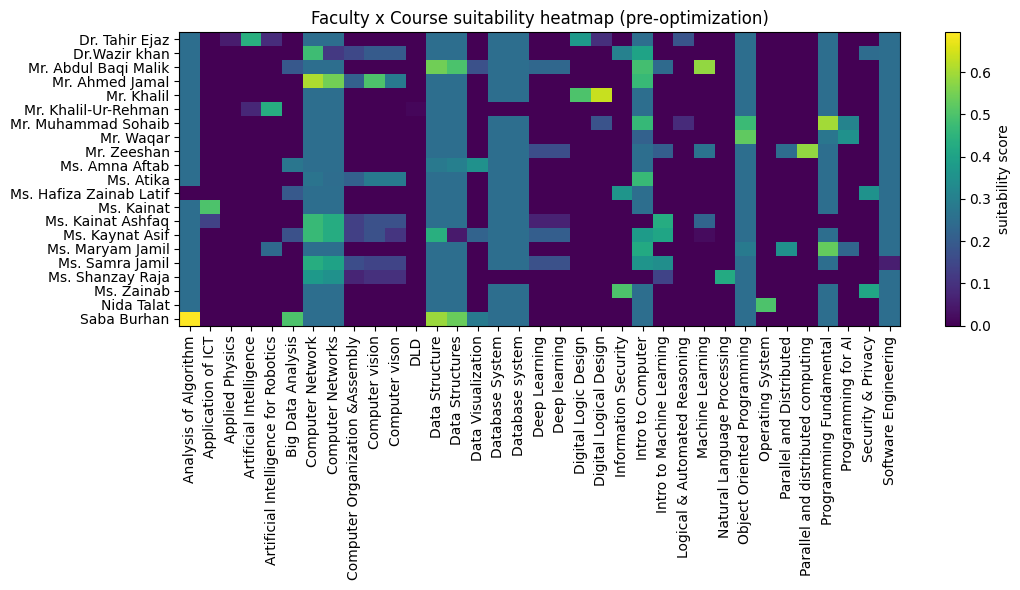

In [14]:
# Heatmap sanity-check of the raw scoring surface before optimization
import matplotlib.pyplot as plt

pivot = result.scores_df.pivot_table(index="faculty_name", columns="course_name", values="score")
plt.figure(figsize=(11, 6))
plt.imshow(pivot.values, aspect="auto", cmap="viridis")
plt.xticks(range(len(pivot.columns)), pivot.columns, rotation=90)
plt.yticks(range(len(pivot.index)), pivot.index)
plt.colorbar(label="suitability score")
plt.title("Faculty x Course suitability heatmap (pre-optimization)")
plt.tight_layout()
plt.show()

### Download the PDF report

In [15]:
pdf_bytes = generate_pdf_report(result, semester_label="Fall 2026")
with open("faculty_workload_report.pdf", "wb") as f:
    f.write(pdf_bytes)

print(f"PDF report written: faculty_workload_report.pdf ({len(pdf_bytes)} bytes)")
if IN_COLAB:
    files.download("faculty_workload_report.pdf")

PDF report written: faculty_workload_report.pdf (12951 bytes)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Section 7 — Path to a trained model (future work, once multi-semester data exists)

Once several semesters of **actual allocation outcomes** exist (not just
who *could* teach what, but who *was* assigned and how it went — student
evaluation scores, whether a faculty member requested that course again),
there are real labels to train against:

1. Build a feature vector per (faculty, course) pair: TF-IDF similarity
   (Section 2), core-course flag, times-taught-before, semesters-since-
   last-taught, program match, credit hours, etc.
2. Label = a target worth predicting — a department review score, or an
   implicit signal like "reassigned the same course again."
3. Train a ranking model (`GradientBoostingRegressor`, or `LGBMRanker`
   with enough pairs) on those features.
4. Replace the `score` column that Section 2 produces with this model's
   predictions — the optimization layer in Section 3 doesn't need to
   change, since it just consumes a score column and enforces
   constraints on top of it.

Left as a stub rather than fabricated against data that doesn't exist
yet — wire it in once real historical outcomes are being tracked.